In [9]:
import tensorflow as tf
import numpy as np
from keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [10]:
model=tf.keras.models.load_model('trained_model.keras')

In [11]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 128, 128, 32)      896       
                                                                 
 conv2d_1 (Conv2D)           (None, 126, 126, 32)      9248      
                                                                 
 max_pooling2d (MaxPooling2  (None, 63, 63, 32)        0         
 D)                                                              
                                                                 
 conv2d_2 (Conv2D)           (None, 63, 63, 64)        18496     
                                                                 
 conv2d_3 (Conv2D)           (None, 61, 61, 64)        36928     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 30, 30, 64)        0         
 g2D)                                                   

## Visualizing Single Image

In [12]:
import cv2

In [13]:
image_path="dataset-2/test/Apple___healthy/00a6039c-e425-4f7d-81b1-d6b0e668517e___RS_HL 7669.JPG"

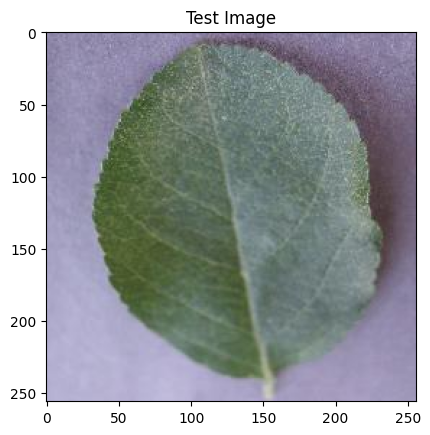

In [14]:
img=cv2.imread(image_path)
img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.title("Test Image")
plt.show()

## Testing Model

In [15]:
image = tf.keras.preprocessing.image.load_img(image_path,target_size=(128,128))
image_arr = tf.keras.preprocessing.image.img_to_array(image)
image_arr=np.array([image_arr])
print(image_arr.shape)

(1, 128, 128, 3)


In [16]:
prediction = model.predict(image_arr)
prediction,prediction.shape

1/1 [==============================] - 0s 176ms/step


2026-04-26 16:33:30.394338: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


(array([[8.5898595e-05, 2.8666391e-04, 2.3243006e-20, 9.9962604e-01,
         9.8355436e-08, 1.0034346e-16, 4.5171669e-07, 2.4457326e-14,
         2.6265304e-15, 9.8575734e-19, 4.9948465e-21, 3.1828556e-24,
         5.5340947e-26, 8.3078099e-28, 7.7886364e-07, 5.4014011e-12,
         3.9264030e-18, 1.4581751e-15, 8.4495901e-28, 1.6205820e-20,
         2.5562497e-15, 4.4594886e-13, 4.9484123e-09, 1.2972764e-19,
         1.3437428e-09, 6.8898767e-12, 2.2785779e-14, 2.1029619e-08,
         2.2814227e-21, 1.7907777e-28, 8.1881605e-27, 3.8535767e-17,
         4.6703865e-20, 5.1900275e-24, 1.5081630e-15, 8.0603799e-28,
         1.7163869e-16, 3.5454598e-13]], dtype=float32),
 (1, 38))

In [17]:
result_index = np.argmax(prediction)
result_index

3

In [18]:
class_name=['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_spider_mite',
 'Tomato___Target_Spot',
 'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
 'Tomato___Tomato_mosaic_virus',
 'Tomato___healthy']

## Display Result

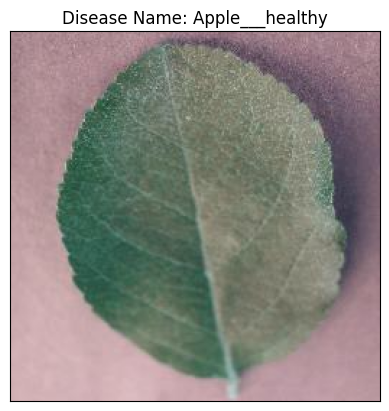

In [19]:
model_prediction = class_name[result_index]

img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.title(f"Disease Name: { model_prediction}")
plt.xticks([])
plt.yticks([])
plt.show()

In [20]:
model_prediction

'Apple___healthy'